In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install gensim

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/GBA 6410 HW/amazon_major_appliances.tsv', on_bad_lines="skip", sep='\t', header=None, names=['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date'])

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/GBA 6410 HW/amazon_major_appliances.tsv', on_bad_lines="skip", sep='\t')

/tmp/ipython-input-5-1628042806.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/GBA 6410 HW/amazon_major_appliances.tsv', on_bad_lines="skip", sep='\t')


In [ ]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,Unnamed: 15
0,US,16199106,R203HPW78Z7N4K,B0067WNSZY,633038551,"FGGF3032MW Gallery Series 30"" Wide Freestandin...",Major Appliances,5,0,0,N,Y,"If you need a new stove, this is a winner.",What a great stove. What a wonderful replacem...,2015/8/31,NaN
1,US,16374060,R2EAIGVLEALSP3,B002QSXK60,811766671,Best Hand Clothes Wringer,Major Appliances,5,1,1,N,Y,Five Stars,worked great,2015/8/31,NaN
2,US,15322085,R1K1CD73HHLILA,B00EC452R6,345562728,Supco SET184 Thermal Cutoff Kit,Major Appliances,5,0,0,N,Y,Fast Shipping,Part exactly what I needed. Saved by purchasi...,2015/8/31,NaN
3,US,32004835,R2KZBMOFRMYOPO,B00MVVIF2G,563052763,Midea WHS-160RB1 Compact Single Reversible Doo...,Major Appliances,5,1,1,N,Y,Five Stars,Love my refrigerator! ! Keeps everything cold...,2015/8/31,NaN
4,US,25414497,R6BIZOZY6UD01,B00IY7BNUW,874236579,Avalon Bay Portable Ice Maker,Major Appliances,5,0,0,N,Y,Five Stars,No more running to the store for ice! Works p...,2015/8/31,NaN


In [ ]:
len(df)

96834

In [ ]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,Unnamed: 15
0,US,16199106,R203HPW78Z7N4K,B0067WNSZY,633038551,"FGGF3032MW Gallery Series 30"" Wide Freestandin...",Major Appliances,5,0,0,N,Y,"If you need a new stove, this is a winner.",What a great stove. What a wonderful replacem...,2015/8/31,NaN
1,US,16374060,R2EAIGVLEALSP3,B002QSXK60,811766671,Best Hand Clothes Wringer,Major Appliances,5,1,1,N,Y,Five Stars,worked great,2015/8/31,NaN
2,US,15322085,R1K1CD73HHLILA,B00EC452R6,345562728,Supco SET184 Thermal Cutoff Kit,Major Appliances,5,0,0,N,Y,Fast Shipping,Part exactly what I needed. Saved by purchasi...,2015/8/31,NaN
3,US,32004835,R2KZBMOFRMYOPO,B00MVVIF2G,563052763,Midea WHS-160RB1 Compact Single Reversible Doo...,Major Appliances,5,1,1,N,Y,Five Stars,Love my refrigerator! ! Keeps everything cold...,2015/8/31,NaN
4,US,25414497,R6BIZOZY6UD01,B00IY7BNUW,874236579,Avalon Bay Portable Ice Maker,Major Appliances,5,0,0,N,Y,Five Stars,No more running to the store for ice! Works p...,2015/8/31,NaN


In [ ]:
reviews = df['review_body'].dropna().tolist()

In [ ]:
def clean_html_and_urls(text):
    text = re.sub(r"<[^>]+>", "", text)      # html
    text = re.sub(r"https?://\S+", "", text) # delete url
    return text

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)       # punctuation
    text = re.sub(r"\s+", " ", text).strip()  # merge space
    return text

normalized = [
    normalize_text(clean_html_and_urls(r))
    for r in reviews
]

In [ ]:
len(normalized)

96827

In [ ]:
lemmatizer = WordNetLemmatizer()
tokenized = [rev.split() for rev in normalized]

# remove stopwords from each token list
stop = set(stopwords.words('english'))
filtered = [
    [tok for tok in tokens if tok not in stop]
    for tokens in tokenized
]
lemmatized = [
    [lemmatizer.lemmatize(tok) for tok in tokens]
    for tokens in filtered
]

lemmatized

[['great',
  'stove',
  'wonderful',
  'replacement',
  'sort',
  'antique',
  'enjoy',
  'every',
  'day'],
 ['worked', 'great'],
 ['part', 'exactly', 'needed', 'saved', 'purchasing'],
 ['love', 'refrigerator', 'keep', 'everything', 'coldwill', 'recommend'],
 ['running', 'store', 'ice', 'work', 'perfectly'],
 ['would',
  'cool',
  '55',
  'degree',
  'stopped',
  'working',
  'together',
  'would',
  'recommend',
  'piece',
  'junk',
  'anyone'],
 ['work',
  'awesome',
  'apt',
  'size',
  '110',
  'dryer',
  'handle',
  'load',
  'apt',
  'size',
  'washer',
  'fine',
  'take',
  'longer',
  'dry',
  'electric',
  'cost',
  'saving',
  'full',
  'size',
  '220',
  'worth',
  'time',
  'add',
  'much',
  'humidity',
  'unless',
  'lint',
  'filter',
  'full'],
 ['exactly', 'wanted'],
 ['advertised'],
 ['work',
  'advertised',
  'poor',
  'insulation',
  'top',
  'like',
  '3rd',
  'shelf',
  'come',
  'handy',
  'smallshort',
  'item'],
 ['worth', '22', 'dollar', 'ive', 'heard', 'beca

In [ ]:
from collections import Counter

In [ ]:
from itertools import chain

In [ ]:
flat_words = list(chain.from_iterable(lemmatized))

word_freq = Counter(flat_words)

In [ ]:
word_freq.most_common(20)

[('one', 38317),
 ('would', 28143),
 ('work', 27758),
 ('water', 27658),
 ('great', 26702),
 ('time', 25586),
 ('get', 24318),
 ('unit', 22384),
 ('like', 22262),
 ('year', 22027),
 ('machine', 21497),
 ('product', 20469),
 ('ice', 20144),
 ('use', 20001),
 ('good', 19282),
 ('washer', 19196),
 ('well', 19024),
 ('part', 17162),
 ('problem', 16605),
 ('new', 15428)]

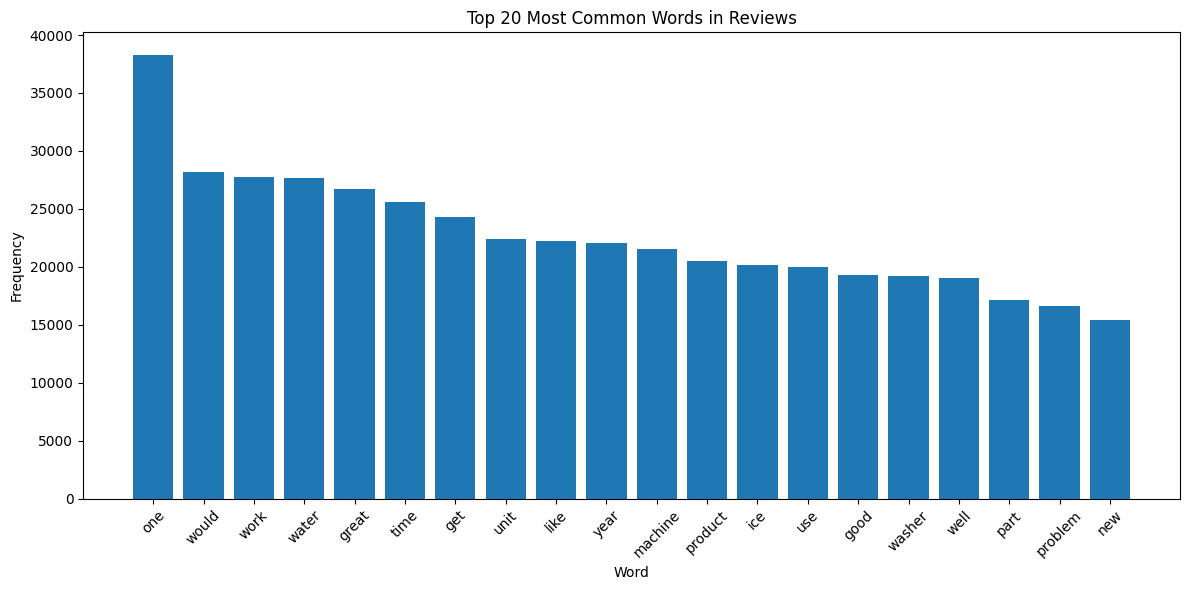

In [ ]:
import matplotlib.pyplot as plt

top_n = 20
top_words = word_freq.most_common(top_n)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title(f"Top {top_n} Most Common Words in Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
pos_tagged = [nltk.pos_tag(tokens) for tokens in lemmatized]
# collect adjective letter
from collections import Counter
adjs = Counter(tok for sent in pos_tagged for tok,pos in sent if pos.startswith('JJ'))
print(adjs.most_common(20))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('great', 26702), ('good', 18902), ('new', 15428), ('easy', 11939), ('little', 11463), ('old', 11265), ('clean', 10089), ('small', 9879), ('much', 9090), ('top', 8259), ('nice', 7359), ('quiet', 6903), ('last', 6719), ('dry', 6530), ('fit', 6396), ('ive', 6138), ('sure', 6034), ('happy', 5871), ('first', 5729), ('perfect', 5474)]


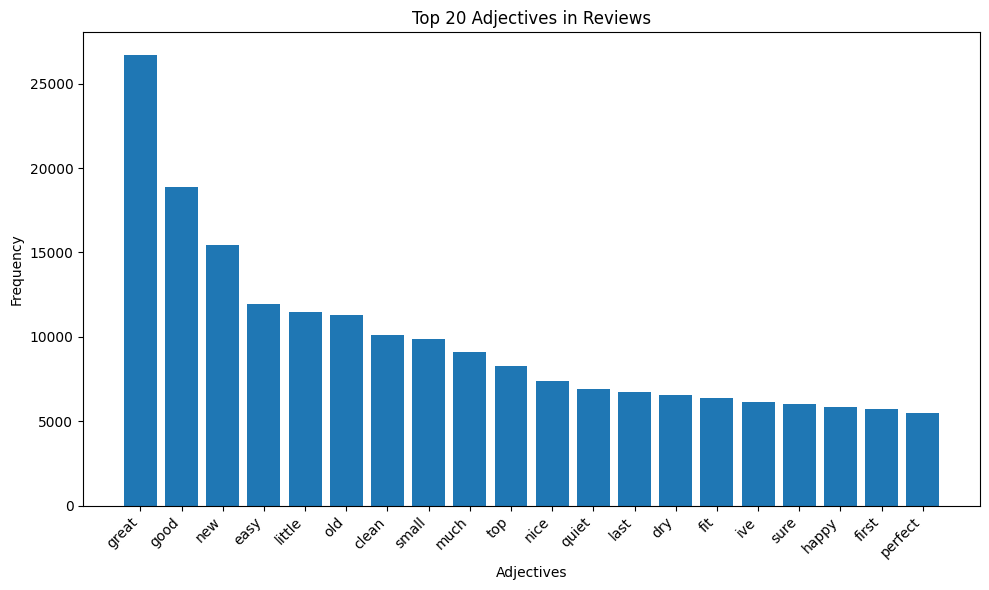

In [ ]:
labels, counts = zip(*adjs.most_common(20))

#  bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Adjectives')
plt.ylabel('Frequency')
plt.title('Top 20 Adjectives in Reviews')
plt.tight_layout()
plt.show()

In [ ]:
NNs = Counter(tok for sent in pos_tagged for tok,pos in sent if pos.startswith('NN'))
print(NNs.most_common(20))

[('water', 27658), ('time', 25586), ('work', 25240), ('unit', 22384), ('year', 22027), ('machine', 21497), ('product', 20469), ('ice', 18218), ('part', 17162), ('problem', 16605), ('use', 15277), ('month', 14701), ('door', 12707), ('thing', 12612), ('service', 12323), ('clothes', 12298), ('fridge', 12292), ('day', 12031), ('price', 11704), ('dryer', 11574)]


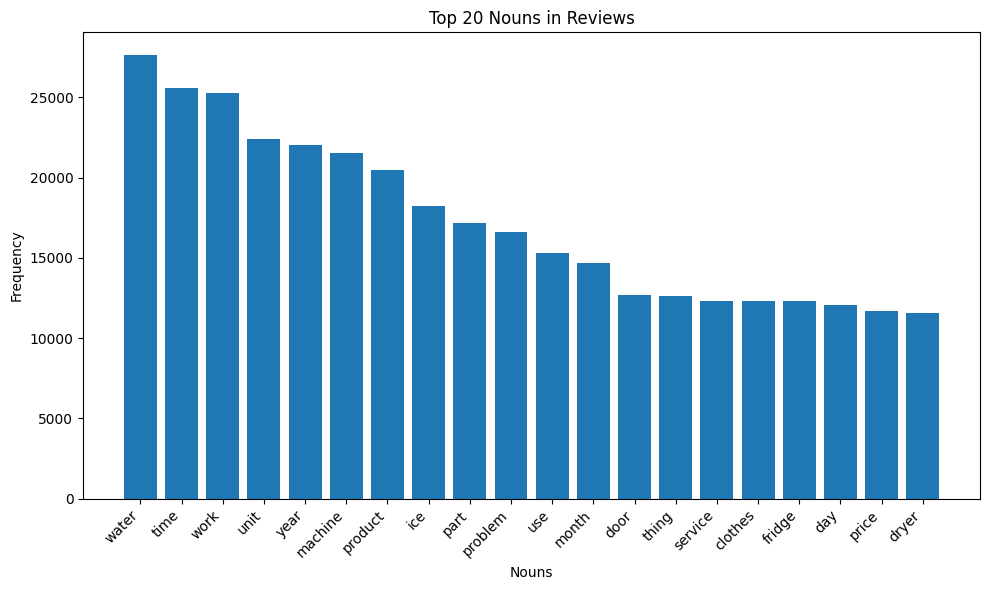

In [ ]:
labels, counts = zip(*NNs.most_common(20))

#  bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Nouns')
plt.ylabel('Frequency')
plt.title('Top 20 Nouns in Reviews')
plt.tight_layout()
plt.show()

##Agent (Sentiment + Topic Extraction)

In [ ]:
pip install ace-tools-open

In [ ]:
# !pip install bertopic

In [ ]:
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import ace_tools_open as tools
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
review_ids = df['review_id']

cleaned_texts = [' '.join(tokens) for tokens in lemmatized]

# Define sentiment function, using TextBlob
# 1. Sentiment Agent
sentiments = ['positive' if TextBlob(text).sentiment.polarity >= 0 else 'negative'
              for text in cleaned_texts]

# 2. Split texts by sentiment.
#    Since LDA computes word frequencies over the entire corpus and there are more positive reviews than negative ones,
#    negative keywords could be drowned out by positive terms if we don’t separate them.
pos_texts = [t for t, s in zip(cleaned_texts, sentiments) if s == 'positive']
neg_texts = [t for t, s in zip(cleaned_texts, sentiments) if s == 'negative']

In [ ]:
# Calculate positive and negative amount
pos_total = 0
neg_total = 0
for i in sentiments:
  if i == 'negative':
    neg_total +=1
  else:
    pos_total +=1
print("Positive total: ",pos_total)
print("Negitive total: ",neg_total)

Positive total:  83159
Negitive total:  13668


In [ ]:
def simple_tokenizer(text: str) -> list:
    return text.split()

In [ ]:
# train LDA model
def train_lda(texts, n_topics=5):
    vec = CountVectorizer(stop_words='english', tokenizer=simple_tokenizer, lowercase=False)
    X = vec.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=10,
        learning_method='batch'
    )
    lda.fit(X)
    # extract each topic 5 key words
    keywords = {
        idx: [vec.get_feature_names_out()[i]
              for i in comp.argsort()[-5:][::-1]]
        for idx, comp in enumerate(lda.components_)
    }
    return vec, lda, keywords

# 4. train pos and neg‘s LDA model
vec_pos, lda_pos, kw_pos = train_lda(pos_texts, n_topics=5)

vec_neg, lda_neg, kw_neg = train_lda(neg_texts, n_topics=5)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
import joblib

In [ ]:
# base_path = '/content/drive/MyDrive/GBA 6410 HW/lda_models'

# joblib.dump(vec_pos,  base_path + 'count_vectorizer_pos.joblib')
# joblib.dump(lda_pos,  base_path + 'lda_pos.joblib')
# joblib.dump(kw_pos,   base_path + 'keywords_pos.joblib')

# joblib.dump(vec_neg,  base_path + 'count_vectorizer_neg.joblib')
# joblib.dump(lda_neg,  base_path + 'lda_neg.joblib')
# joblib.dump(kw_neg,   base_path + 'keywords_neg.joblib')

['/content/drive/MyDrive/GBA 6410 HW/lda_modelskeywords_neg.joblib']

In [ ]:
# base_path = '/content/drive/MyDrive/GBA 6410 HW/lda_models'

# vec_pos = joblib.load(base_path + 'count_vectorizer_pos.joblib')
# lda_pos = joblib.load(base_path + 'lda_pos.joblib')
# kw_pos  = joblib.load(base_path + 'keywords_pos.joblib')

# vec_neg = joblib.load(base_path + 'count_vectorizer_neg.joblib')
# lda_neg = joblib.load(base_path + 'lda_neg.joblib')
# kw_neg  = joblib.load(base_path + 'keywords_neg.joblib')

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

In [ ]:
# 1. token list
pos_tokens = [tokens for tokens, s in zip(lemmatized, sentiments) if s == 'positive']
neg_tokens = [tokens for tokens, s in zip(lemmatized, sentiments) if s == 'negative']

# 2. Dictionary
dict_pos = Dictionary(pos_tokens)
dict_neg = Dictionary(neg_tokens)


topics_neg = list(kw_neg.values())

# 4. Coherence score
cm_pos = CoherenceModel(
    topics=topics_pos,
    texts=pos_tokens,
    dictionary=dict_pos,
    coherence='c_v'
)
coherence_pos = cm_pos.get_coherence()

cm_neg = CoherenceModel(
    topics=topics_neg,
    texts=neg_tokens,
    dictionary=dict_neg,
    coherence='c_v'
)
coherence_neg = cm_neg.get_coherence()

print(f"Positive coherence (C_V): {coherence_pos:.4f}")
print(f"Negative coherence (C_V): {coherence_neg:.4f}")

Positive coherence (C_V): 0.5935
Negative coherence (C_V): 0.5915


In [ ]:
score_pos = cm_pos.get_coherence()
score_neg = cm_neg.get_coherence()

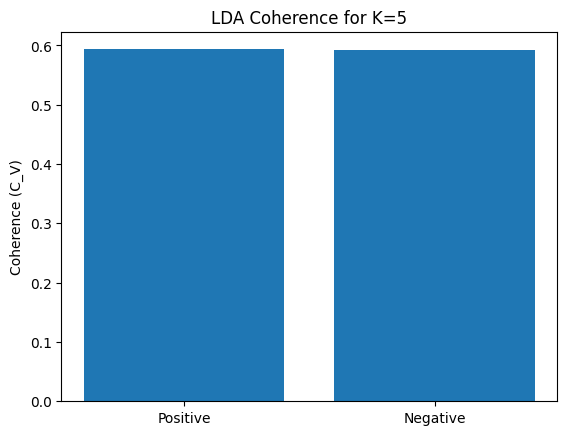

In [ ]:

plt.bar(['Positive','Negative'], [score_pos, score_neg])
plt.ylabel('Coherence (C_V)')
plt.title('LDA Coherence for K=5')
plt.show()

In [ ]:
# lda_pos.save("/content/drive/MyDrive/Colab Notebooks/LDA_pos")
# lda_neg.save("/content/drive/MyDrive/Colab Notebooks/LDA_neg")

In [ ]:
# 5. define extraction function
def extract_insights(text, sentiment):
    if sentiment == 'positive':
        topic_id = lda_pos.transform(vec_pos.transform([text])).argmax()
        return kw_pos[topic_id]
    else:
        topic_id = lda_neg.transform(vec_neg.transform([text])).argmax()
        return kw_neg[topic_id]
def orchestrator(review_ids, texts, sentiments):
    """
    combine sentiment and extraction Agent
    return：[{ 'review_id': ..., 'sentiment': ..., 'key_insights': [...] }, …]
    """
    results = []
    for rid, text, sent in zip(review_ids, texts, sentiments):
        insights = extract_insights(text, sent)
        results.append({
            'review_id': rid,
            'sentiment':  sent,
            'key_insights': insights
        })
    return results

# use orchestrator to execute both function
records = orchestrator(review_ids, cleaned_texts, sentiments)
df_output = pd.DataFrame(records)
print(df_output)

            review_id sentiment                                   key_insights
0      R203HPW78Z7N4K  positive           [oven, range, microwave, look, hood]
1      R2EAIGVLEALSP3  positive             [great, work, fit, product, price]
2      R1K1CD73HHLILA  positive             [great, work, fit, product, price]
3      R2KZBMOFRMYOPO  positive        [fridge, door, unit, wine, temperature]
4       R6BIZOZY6UD01  positive             [great, work, fit, product, price]
...               ...       ...                                            ...
96822  R3JNS5SZ2W3SZL  positive  [washer, machine, water, clothes, dishwasher]
96823  R29AX0PMYDL4FP  negative              [ice, maker, product, time, work]
96824  R3ANFDBFD1VYKR  positive  [washer, machine, water, clothes, dishwasher]
96825  R1LNYMXEM9TSB2  positive        [fridge, door, unit, wine, temperature]
96826  R3QG51IIJACH2P  positive             [great, work, fit, product, price]

[96827 rows x 3 columns]


In [ ]:
df_output = pd.read_csv('/content/drive/MyDrive/GBA 6410 HW/output_LDA.csv')

In [ ]:
# 统计指定情感类别的 Top N 关键词
def top_keywords_by_sentiment(df, sentiment, top_n=5):
    subset = df[df['sentiment'] == sentiment]
    all_keywords = subset['key_insights'].explode()
    counts = all_keywords.value_counts().head(top_n)
    return counts.reset_index().rename(columns={'index':'keyword', 'key_insights':'count'})

# 计算正面和负面 Top 5
top_pos = top_keywords_by_sentiment(df_output, 'positive', top_n=5)
top_neg = top_keywords_by_sentiment(df_output, 'negative', top_n=5)

print("Top 5 Keywords for Positive Reviews:")
print(top_pos)

print("\nTop 5 Keywords for Negative Reviews:")
print(top_neg)

Top 5 Keywords for Positive Reviews:
                                               count  count
0       ['great', 'work', 'fit', 'product', 'price']  28333
1       ['ice', 'year', 'service', 'month', 'water']  14652
2  ['fridge', 'door', 'unit', 'wine', 'temperature']  13529
3  ['washer', 'machine', 'water', 'clothes', 'dis...  13457
4     ['oven', 'range', 'microwave', 'look', 'hood']  13188

Top 5 Keywords for Negative Reviews:
                                               count  count
0  ['year', 'service', 'product', 'warranty', 'mo...   4240
1           ['cold', 'oven', 'work', 'unit', 'like']   3059
2  ['machine', 'washer', 'water', 'clothes', 'load']   2633
3  ['water', 'filter', 'door', 'unit', 'refrigera...   2132
4        ['ice', 'maker', 'product', 'time', 'work']   1604


In [ ]:
df_output.to_csv('output_LDA.csv', index=False)

In [ ]:
key_words = df_output['key_insights'].dropna()

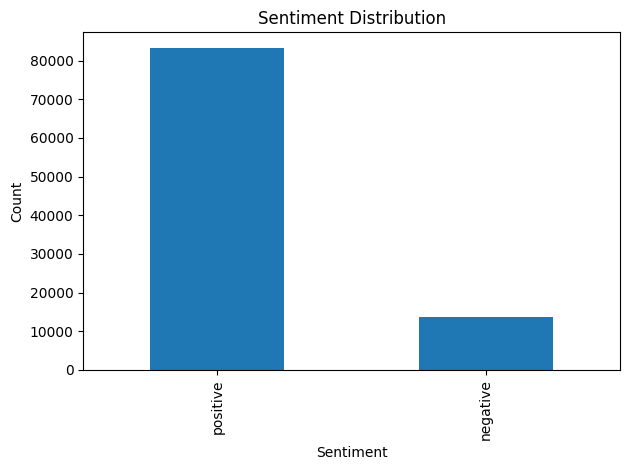

In [ ]:

sentiment_counts = df_output['sentiment'].value_counts()
plt.figure()
sentiment_counts.plot.bar()
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

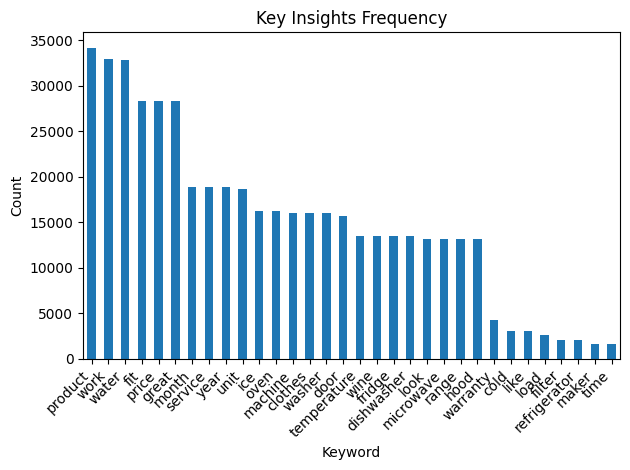

In [ ]:
# 2. Plot key insights frequency
df_exploded = df_output.explode('key_insights')
keyword_counts = df_exploded['key_insights'].value_counts()
plt.figure()
keyword_counts.plot.bar()
plt.title('Key Insights Frequency')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

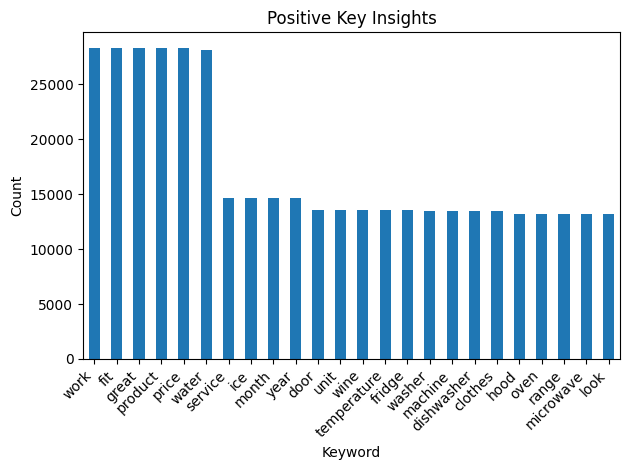

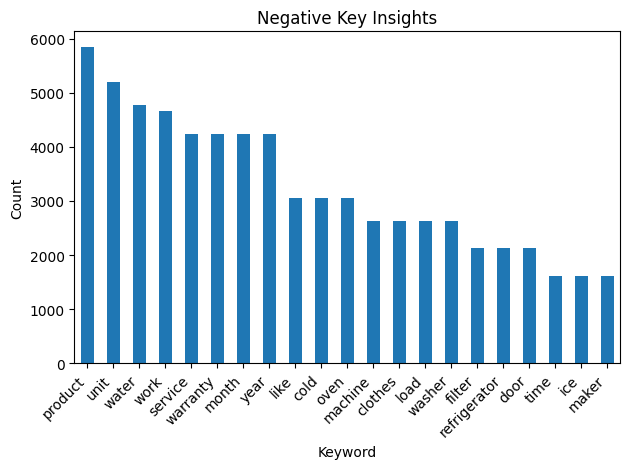

In [ ]:
# Explode key_insights into individual rows
df_exploded = df_output.explode('key_insights')

# Calculate frequencies per sentiment
pos_counts = df_exploded[df_exploded.sentiment == 'positive']['key_insights'].value_counts()
neg_counts = df_exploded[df_exploded.sentiment == 'negative']['key_insights'].value_counts()

# Plot Positive Key Insights
plt.figure()
pos_counts.plot.bar()
plt.title('Positive Key Insights')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Negative Key Insights
plt.figure()
neg_counts.plot.bar()
plt.title('Negative Key Insights')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# from sentence_transformers import SentenceTransformer

# embedder = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# embeddings = embedder.encode(
#     cleaned_texts,
#     show_progress_bar=True,
#     device="cuda",
#     batch_size=32
# )

Batches:   0%|          | 0/3026 [00:00<?, ?it/s]

In [ ]:
# %%bash
# while true; do
#   nvidia-smi
#   sleep 2
# done

Process is interrupted.


In [ ]:
# train Bertopic model
# vectorizer_model = CountVectorizer(
#     tokenizer=lambda x: x.split(),
#     lowercase=False,
#     stop_words="english"
# )
# topic_model = BERTopic(
#     embedding_model=None,
#     vectorizer_model=vectorizer_model,
#     nr_topics="auto",
#     calculate_probabilities=True
# )

# topics, probs = topic_model.fit_transform(cleaned_texts, embeddings)